# X-ray spectra by epoch: best-fit model per epoch

Companion to `xray_spectra_by_epoch.ipynb` and the per-model comparison figures
(`xray_spectra_{apec,powerlaw,bremss,bremss_powerlaw}_fit.ipynb`), but instead of
holding the model fixed across epochs, this figure shows **each epoch's own
best-fit model**, per the user's `xray_epoch_spec_models.xlsx` (2026-09-04):

| Epoch | Adopted model | Notes |
|---|---|---|
| 20306 (~13 d) | `tbabs*powerlaw`, N_H frozen at Galactic | Thawing N_H didn't meaningfully improve this fit (see `CLAUDE_xray_SOP.md` Step 4, collaborator guidance 2026-09-03) -- the user's table picks the simpler frozen-N_H version (rstat=2.27) over the free-N_H one (rstat=2.44) that's saved as the "production" `fits/powerlaw/` output used in the 4-model comparison figures. Refit separately here as `fits/powerlaw_nh_frozen/` (`fit_20306_powerlaw_frozen_nh.py`) so this figure doesn't disturb those existing figures' fit. |
| 29071+29072 (~1869 d) | `tbabs*(bremss+powerlaw)` | Best of the 4 continuum models tried, though under-constrained either way (only 109 counts) -- reuses the existing `fits/bremss_powerlaw/` output unchanged. |
| 31211+31996 (~2550 d) | `tbabs*(bremss+gauss)`, free-centroid Gaussian | The line-addition result adopted 2026-09-04 (E=2.957+/-0.032 keV, sigma=0.055 keV, resolution-limited -- see Step 4 "Done 2026-09-03 -- Gaussian component added"). Reuses the existing `fits/bremss_gauss/` output unchanged. |

Same 3-panel, chronological, 2-row (spectrum + residuals) layout as the other
X-ray fit-comparison figures, `group_counts(15)`, 0.3-8 keV, wstat. Colors: each
epoch's data points use its position in the single project-wide viridis epoch list
(`CLAUDE_plotting.md`); the best-fit model curve uses a darkened version of the
same epoch color (`darken_color`), consistent with the other X-ray fit figures --
since every panel here has a *different* model, there's no shared "one model
color" the way the per-model comparison figures have, so the epoch-color link is
the only consistent color rule that still applies.

Run under the `18ivc_clean` kernel -- fitting itself was done separately under
`ciao-4.17` (Sherpa); see `CLAUDE_xray_SOP.md` Step 4 for full fit details.

In [1]:
import sys, os
sys.path.append(os.path.abspath(".."))

import pandas as pd
import numpy as np
import matplotlib as mpl
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
from astropy.io import fits
from astropy.time import Time
import functions

functions.set_plot_style()

GROUPING_QA_DIR = "../data/Chandra/spectral_fitting/grouping_qa"
FITS_DIR = "../data/Chandra/spectral_fitting/fits"
T_EXPLOSION_MJD = 58445.0  # Maeda et al. 2023a

# (epoch_key, display_label, source PHA path, model dir name, summary csv, model title)
EPOCHS_INFO = [
    ("20306", "20306", "../data/Chandra/20306/repro/SN2018ivc_specextract.pi",
     "powerlaw_nh_frozen", f"{FITS_DIR}/fit_summary_powerlaw_nh_frozen.csv",
     "Power Law (N$_H$ frozen)"),
    ("29071_29072", "29071+29072", "../data/Chandra/29071_29072_merged/SN2018ivc_merged_src.pi",
     "bremss_powerlaw", f"{FITS_DIR}/fit_summary.csv",
     "Bremsstrahlung + Power Law"),
    ("31211_31996", "31211+31996", "../data/Chandra/31211_31996_merged/SN2018ivc_merged_src.pi",
     "bremss_gauss", f"{FITS_DIR}/fit_summary_gauss.csv",
     "Bremsstrahlung + Gaussian"),
]

# Position of each X-ray epoch in the single project-wide viridis epoch list
# (CLAUDE_plotting.md "Epoch -> viridis color (SEDs)", x = linspace(1,0,11)).
EPOCH_VIRIDIS_X = {
    "20306": 0.900,
    "29071_29072": 0.400,
    "31211_31996": 0.100,
}

def darken_color(color, factor=0.6):
    rgb = mcolors.to_rgb(color)
    return tuple(factor * c for c in rgb)

cmap = mpl.colormaps["viridis"]
epoch_colors = {k: cmap(x) for k, x in EPOCH_VIRIDIS_X.items()}
model_colors = {k: darken_color(c) for k, c in epoch_colors.items()}

def epoch_title(display_label, path):
    h = fits.open(path)[1].header
    date_obs = h["DATE-OBS"][:10]
    mjd = Time(h["DATE-OBS"], format="isot", scale="utc").mjd
    phase_days = mjd - T_EXPLOSION_MJD
    return f"{display_label} ({date_obs}, ~{phase_days:.0f} days post-explosion)", phase_days

panels = []
for epoch_key, display_label, path, model_dir, summary_csv, model_title in EPOCHS_INFO:
    title, phase_days = epoch_title(display_label, path)
    panels.append((phase_days, epoch_key, title, model_dir, summary_csv, model_title))
panels.sort(key=lambda p: p[0])

def param_label(row, val_col, label, unit, fmt="{:.2f}"):
    pegged = row.get(f"{val_col}_pegged", False)
    val = row[f"{val_col}_val"]
    val_s = fmt.format(val)
    unit_s = f" {unit}" if unit else ""
    if pegged:
        return f"{label} = {val_s}{unit_s} (pegged at bound)"
    lo, hi = row.get(f"{val_col}_errlo"), row.get(f"{val_col}_errhi")
    if pd.notna(lo) and pd.notna(hi):
        return f"{label} = {val_s}$^{{+{fmt.format(hi)}}}_{{{fmt.format(lo)}}}${unit_s}"
    return f"{label} = {val_s}{unit_s} (unconstrained)"

def fit_label(epoch_key, model_dir, summary_csv):
    summary = pd.read_csv(summary_csv, dtype={"epoch": str})
    model_col = "model"
    row_name = model_dir
    row = summary[(summary[model_col] == row_name) & ((summary.get("epoch") == epoch_key) if "epoch" in summary.columns else True)]
    row = row.iloc[0]

    if model_dir == "powerlaw_nh_frozen":
        lines = [
            param_label(row, "pl1.PhoIndex", r"$\Gamma$", ""),
            r"$N_H$ = 2.6$\times10^{20}$ cm$^{-2}$",
        ]
    elif model_dir == "bremss_powerlaw":
        lines = [
            param_label(row, "brem1.kT", "kT", "keV"),
            param_label(row, "pl1.PhoIndex", r"$\Gamma$", ""),
        ]
    elif model_dir == "bremss_gauss":
        lines = [
            param_label(row, "brem1.kT", "kT", "keV"),
            param_label(row, "gau1.LineE", "E$_{line}$", "keV", fmt="{:.3f}"),
            r"$\sigma$ = 0.055 keV (resolution-limited)",
        ]
    statval, dof = row["statval"], row["dof"]
    lines.append(f"$W$/dof = {statval:.1f}/{dof:.0f}")
    return "\n".join(lines)


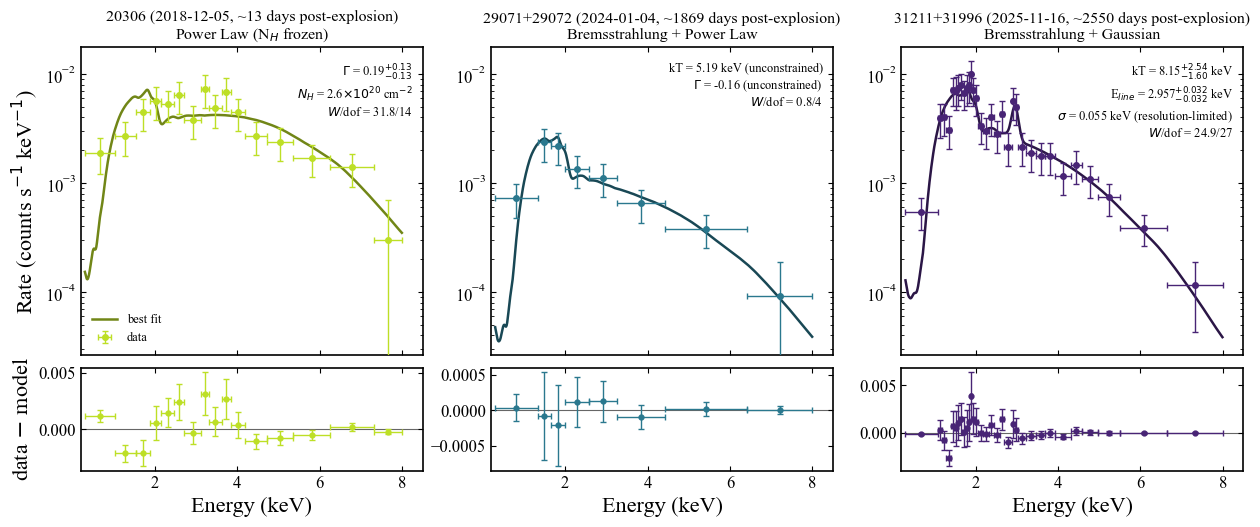

In [2]:
fig = plt.figure(figsize=(15, 5.5))
gs = fig.add_gridspec(2, 3, height_ratios=[3, 1], hspace=0.06)

spec_axes = [fig.add_subplot(gs[0, 0])]
spec_axes += [fig.add_subplot(gs[0, i], sharex=spec_axes[0], sharey=spec_axes[0]) for i in (1, 2)]
resid_axes = [fig.add_subplot(gs[1, i], sharex=spec_axes[i]) for i in range(3)]

for ax, rax, (phase_days, epoch_key, title, model_dir, summary_csv, model_title) in zip(spec_axes, resid_axes, panels):
    df = pd.read_csv(f"{GROUPING_QA_DIR}/{epoch_key}_group15.csv")
    ax.errorbar(
        df["energy_kev"], df["rate"],
        xerr=df["energy_err_kev"], yerr=df["rate_err"],
        fmt="o", ms=4, capsize=2, lw=1.2, elinewidth=1,
        color=epoch_colors[epoch_key], zorder=3, label="data",
    )

    mdf = pd.read_csv(f"{FITS_DIR}/{model_dir}/{epoch_key}_model.csv")
    ax.plot(mdf["energy_kev"], mdf["rate"], "-", color=model_colors[epoch_key], lw=1.8, zorder=2, label="best fit")

    ax.set_title(f"{title}\n{model_title}", fontsize=11.5)
    ax.set_yscale("log")
    ax.set_xlim(0.2, 8.5)
    ax.text(
        0.97, 0.95, fit_label(epoch_key, model_dir, summary_csv), transform=ax.transAxes,
        ha="right", va="top", fontsize=9,
    )
    plt.setp(ax.get_xticklabels(), visible=False)

    rdf = pd.read_csv(f"{FITS_DIR}/{model_dir}/{epoch_key}_resid.csv")
    rax.axhline(0, color="0.4", lw=0.8, zorder=1)
    rax.errorbar(
        rdf["energy_kev"], rdf["resid"],
        xerr=rdf["energy_err_kev"], yerr=rdf["resid_err"],
        fmt="o", ms=3.5, capsize=2, lw=1.0, elinewidth=1,
        color=epoch_colors[epoch_key], zorder=3,
    )
    rax.set_xlim(0.2, 8.5)
    rax.set_xlabel("Energy (keV)")

spec_axes[0].set_ylabel(r"Rate (counts s$^{-1}$ keV$^{-1}$)")
spec_axes[0].legend(fontsize=9, frameon=False, loc="lower left")
resid_axes[0].set_ylabel("data $-$ model")

fig.savefig("../figures/xray_spectra_best_model_by_epoch.png", dpi=400, bbox_inches="tight")
fig.savefig("../figures/xray_spectra_best_model_by_epoch.pdf", bbox_inches="tight")
plt.show()
